# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [2]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 2.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 4.0 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [gymnasium]/4 [gymnasium]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/home/eliyashev/SHAD/ML/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
/home/eliyashev/SHAD/ML/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


state vector dim = 4
n_actions = 2


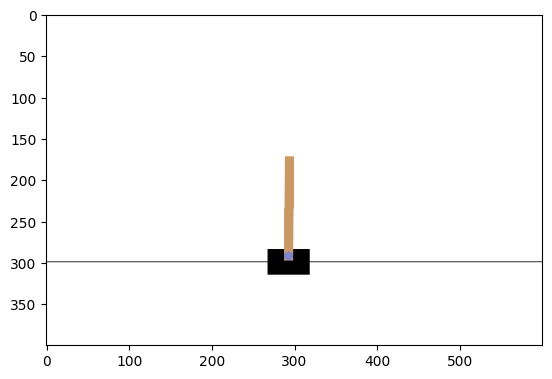

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [2]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes = range(n_actions))


,hidden_layer_sizes,"(20, ...)"
,activation,'tanh'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,None


In [3]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba(s[None,:]).reshape((-1,))

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(range(env.action_space.n),p = probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [4]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 0.03913112 -0.01543064 -0.0480456   0.02362461]
 [ 0.03882251  0.18034622 -0.04757311 -0.2838218 ]
 [ 0.04242943  0.3761133  -0.05324954 -0.5911214 ]
 [ 0.0499517   0.57193875 -0.06507197 -0.9000912 ]
 [ 0.06139047  0.37775606 -0.08307379 -0.62855124]]
actions: [1, 1, 1, 0, 1]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [5]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """
    elite_states = []
    elite_actions = []
    percentile_val = np.percentile(rewards_batch,percentile)
    for i in range(len(states_batch)):
        if rewards_batch[i] >= percentile_val:
            elite_states += states_batch[i]
            elite_actions += actions_batch[i]

    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [6]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()



mean reward = 192.290, threshold=215.600


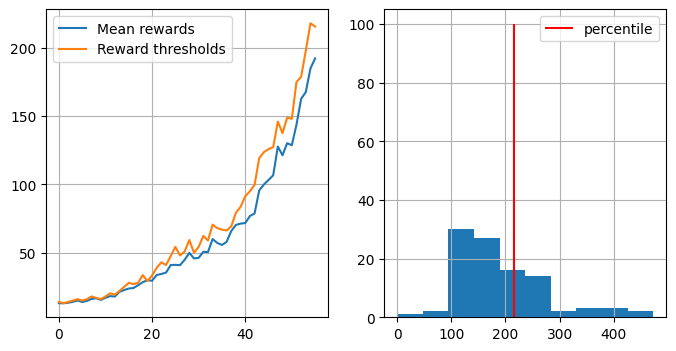

You Win! You may stop training now via KeyboardInterrupt.


In [8]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation="tanh",
    alpha=0.0001
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes = range(n_actions))

n_sessions = 100
percentile = 70
n_epochs = 100
percentile = 70
log = []

for i in range(n_epochs):
    # generate new sessions
    sessions = [generate_session(env, agent, t_max=1000) for _ in range(n_sessions)]

    states_batch = [session[0] for session in sessions]
    actions_batch = [session[1] for session in sessions]
    rewards_batch = [session[2] for session in sessions]

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(elite_states,elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")
        break


# Results

In [7]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


/home/eliyashev/SHAD/ML/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


DependencyNotInstalled: MoviePy is not installed, run `pip install "gymnasium[other]"`

In [ ]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


Ниже идут куски кода из заполненного семинарского ноутбука для такси. Пото я обучаю такси на положительный средний скор, для этого я использую шедулер который постепенно понижает персентиль чтобы не было переобучения. А так же провожу эксперименты для разных персентилей и количества сессий.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Taxi-v3", render_mode="rgb_array")
print(env.reset(seed=0))

n_states = env.observation_space.n
n_actions = env.action_space.n

def initialize_policy(n_states, n_actions):
    policy = np.ones(shape=(n_states,n_actions))/ (n_actions)

    return policy

def generate_session(env, policy, t_max=10**4):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.0
    n_actions = policy.shape[1]
    s, _ = env.reset()

    for t in range(t_max):
        # Hint: you can use np.random.choice for sampling action
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

        a = np.random.choice(range(n_actions),p = policy[s,:] )

        new_s, r, terminated, truncated, _ = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """
    elite_states = []
    elite_actions = []
    reward_threshold = np.percentile(rewards_batch,percentile)
    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states += states_batch[i]
            elite_actions += actions_batch[i]

    return elite_states, elite_actions

def get_new_policy(elite_states, elite_actions):
    """
    Given a list of elite states/actions from select_elites,
    return a new policy where each action probability is proportional to

        policy[s_i,a_i] ~ #[occurrences of s_i and a_i in elite states/actions]

    Don't forget to normalize the policy to get valid probabilities and handle the 0/0 case.
    For states that you never visited, use a uniform distribution (1/n_actions for all states).

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions

    """

    new_policy = np.zeros([n_states, n_actions])
    unvisited = set(range(n_states))
    for state, action in zip(elite_states,elite_actions):
        new_policy[state,action] += 1
        if state in unvisited:
            unvisited.remove(state)
    for state in unvisited:
        new_policy[state,:] = np.ones(n_actions)
    for state in range(n_states):
        new_policy[state,:] /= np.sum(new_policy[state,:])


    return new_policy

from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()
    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()

(314, {'prob': 1.0, 'action_mask': array([1, 1, 0, 0, 0, 0], dtype=int8)})


mean reward = 2.856, threshold=6.000


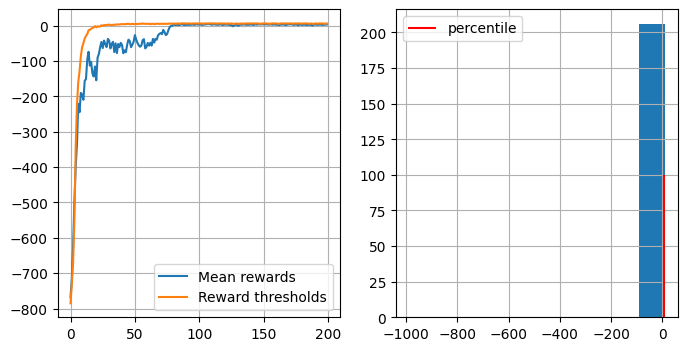

In [2]:
n_sessions = 250  # sample this many sessions
percentile = 50  # discard this percentage of sessions with lowest rewards
learning_rate = 0.5  # how quickly the policy is updated, on a scale from 0 to 1

def sheduler(iter):
    if iter < 10:
        return 80
    if iter < 20:
        return 50
    if iter < 60:
        return 20
    if iter < 100:
        return 10
    return 5



log = []
policy = initialize_policy(n_states, n_actions)
for i in range(200):
    sessions = [ generate_session(env, policy, t_max=10**4) for _ in range(n_sessions) ]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch,sheduler(i))

    new_policy = get_new_policy(elite_states, elite_actions)

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)

Ниже я провожу эксперименты для разного количества сессий и разных персентилей. Вывод: чем больше сессий тем менее шумное обучение, большая персентиль приводит к более быстрому обучению, но начиная с какой-то итерации происходит переобучение - награда в элитных сессиях растёт, а средняя награда падает - агент выбирает рисковые политики которые в небольшом количестве случаев дают высокую награду, но в среднем ведут к проигрышу. 

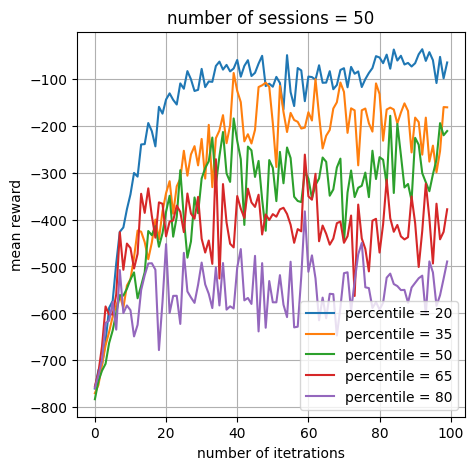

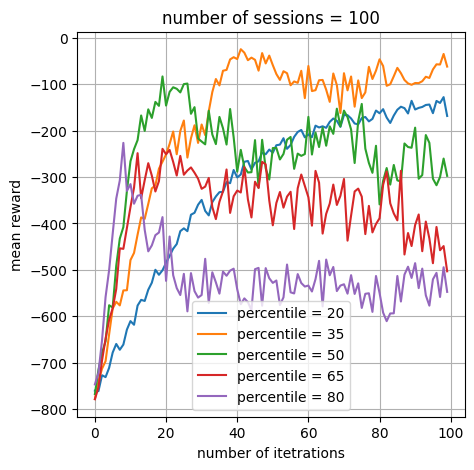

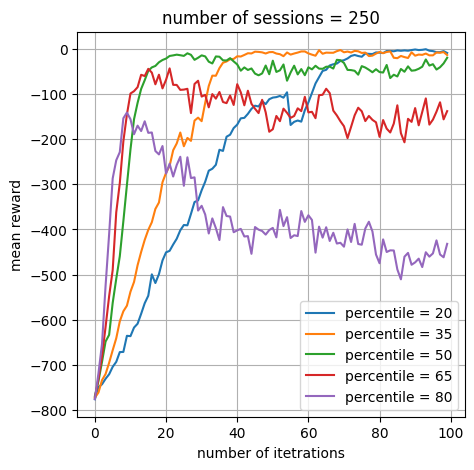

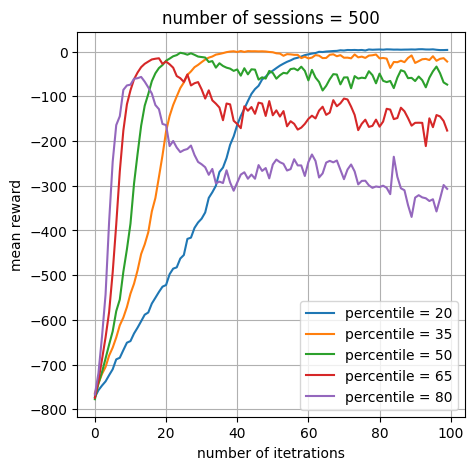

In [3]:
def training_loop(n_sessions,percentile,learning_rate, n_epochs):
    # n_sessions = 250  # sample this many sessions
    # percentile = 50  # discard this percentage of sessions with lowest rewards
    # learning_rate = 0.5  # how quickly the policy is updated, on a scale from 0 to 1

    log = []
    policy = initialize_policy(n_states, n_actions)
    for i in range(n_epochs):
        sessions = [ generate_session(env, policy, t_max=10**4) for _ in range(n_sessions) ]

        states_batch, actions_batch, rewards_batch = zip(*sessions)

        elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch,percentile)

        new_policy = get_new_policy(elite_states, elite_actions)

        policy = learning_rate * new_policy + (1 - learning_rate) * policy

        # display results on chart
        #show_progress(rewards_batch, log, percentile)
        mean_reward = np.mean(rewards_batch)

        log.append(mean_reward)
    return log

# for n_sessions in [50,100,250,500]:
#     for percentile in [20,35,50,65,80]:
for n_sessions in [50,100,250,500]:
    plt.figure(figsize=[5, 5])

    for percentile in [20,35,50,65,80]:
        log = training_loop(n_sessions = n_sessions,percentile = percentile,learning_rate  = 0.5, n_epochs= 100) 
        plt.plot(log, label=f"percentile = {percentile}")
    plt.title(f"number of sessions = {n_sessions}")
    plt.legend()
    plt.grid()
    plt.xlabel('number of itetrations')
    plt.ylabel('mean reward')
    plt.show()


# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

#### Выводы второй части

Я взял LunarLander-v2 использовал распараллеливание разыгрывания сессий и очередь из элитных сессий за последние 3 эпохи и более глубокую и широку сетку с relu. В итоге оба порога побиты.

state vector dim = 8
n_actions = 4


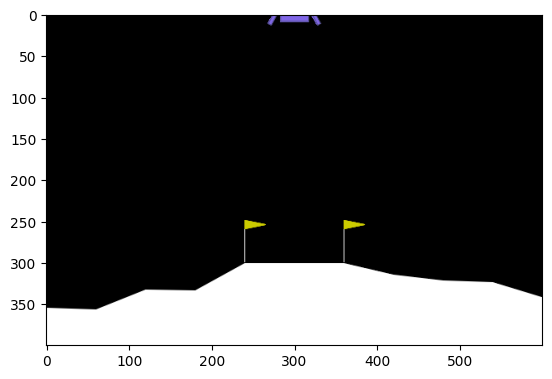

In [8]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("LunarLander-v3", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)


In [78]:
#обертка для нескольких окружений чтобы их можно было вызывать в параллель

import gymnasium as gym

class ParralellEnvs:
    def __init__(self,env_name,n_workers,continuous = False):
        self.envs = []
        self.n_workers = n_workers
        self.continuous = continuous
        for i in range(n_workers):
            env = gym.make(env_name, render_mode="rgb_array",continuous = continuous).env
            env.reset()
            self.envs.append(env)
            
    def generate_session(self, session_n, agent, t_max,std = 0.1):
        if self.continuous:
            return generate_session_cont(self.envs[session_n%self.n_workers], agent, std = std, t_max=t_max)
        return generate_session(self.envs[session_n%self.n_workers], agent, t_max=t_max)
        

In [59]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """
    elite_states = []
    elite_actions = []
    weights = []
    percentile_val = np.percentile(rewards_batch,percentile)
    for i in range(len(states_batch)):
        if rewards_batch[i] > percentile_val:
            elite_states += states_batch[i]
            elite_actions += actions_batch[i]

    return elite_states, elite_actions


mean reward = 202.996, threshold=225.175


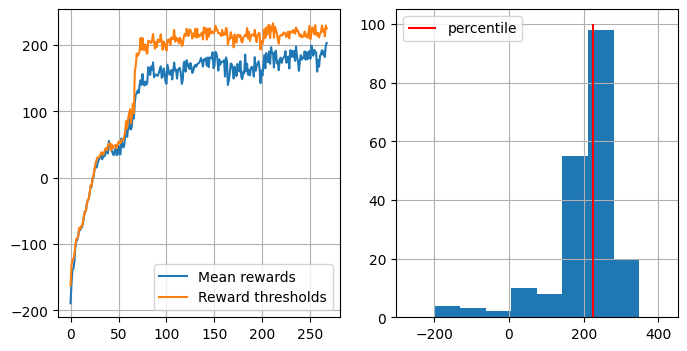

It works well enough


In [ ]:
from sklearn.neural_network import MLPClassifier
from joblib import Parallel, delayed
from collections import deque

agent = MLPClassifier(
    hidden_layer_sizes=(64, 64, 64, 64),
    activation="relu",
    learning_rate_init= 0.001
)

n_workers = 12
n_sessions = 200
percentile =50
n_epochs = 500
t_max = 1000
deque_len = 4 

envs = ParralellEnvs("LunarLander-v3",n_workers=n_workers)
n_actions = envs.envs[0].action_space.n

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([envs.envs[0].reset()[0]] * n_actions, range(n_actions), classes = range(n_actions))

parallel = Parallel(n_jobs=n_workers, return_as="list")
log = []

# Добавил очередь для элит с прошлых эпох
states_deque = deque()
actions_deque = deque()
for i in range(n_epochs):
    print(f"iter num = {i}")
    # генерируем сесси в параллель
    sessions = parallel(delayed(envs.generate_session)(i, agent, t_max=t_max) for i in range(n_sessions))

    states_batch = [session[0] for session in sessions]
    actions_batch = [session[1] for session in sessions]
    rewards_batch = [session[2] for session in sessions]
    
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    states_deque.append(elite_states)
    actions_deque.append(elite_actions)

    for elite_states,elite_actions in zip(states_deque,actions_deque):
        if len(elite_states) > 0:
            agent.partial_fit(elite_states,elite_actions)

    if len(states_deque) >= deque_len:
        states_deque.popleft()
        actions_deque.popleft()


    show_progress(
        rewards_batch, log, percentile, reward_range=[np.min(rewards_batch)-100, np.max(rewards_batch)+100]
    )

    if np.mean(rewards_batch) > 200:
        print("It works well enough")
        break


In [18]:
import pickle

# Define the filename
filename = 'lunar_lander_agent.pkl'

# Open the file in write binary mode and dump the model
with open(filename, 'wb') as file:
    pickle.dump(agent, file)

In [ ]:
filename = 'lunar_lander_agent.pkl'

# Open the file in read binary mode and load the model
with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)


In [ ]:
def visualize_mountain_car(env, agent):
    # Compute policy for all possible x and v (with discretization)
    xs = np.linspace(env.min_position, env.max_position, 100)
    vs = np.linspace(-env.max_speed, env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    # # The above code is equivalent to the following:
    # probs = np.empty((len(vs), len(xs), 3))
    # for i, v in enumerate(vs[::-1]):
    #     for j, x in enumerate(xs):
    #         probs[i, j, :] = agent.predict_proba([[x, v]])[0]

    # Draw policy
    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(env.min_position, env.max_position, -env.max_speed, env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    # Sample a trajectory and draw it
    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white")

    # Draw every 3rd action from the trajectory
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.1, 0, color="white", head_length=0.02)
        elif a == 2:
            plt.arrow(x, v, 0.1, 0, color="white", head_length=0.02)


with gym.make("MountainCar-v0", render_mode="rgb_arrary").env as env:
    visualize_mountain_car(env, agent)


### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.

#### Выводы бонусной части

Ниже реализуется Lunar Lander с непрервыным управлением. К управлению агента добавляется нормальный шум с дисперсией затухающей для по мере роста средней награды агента. Поскольку можно считать что в этой задаче упарвление это два числа от -1 до 1, то выходам MLPRegressor-а добавлялся нормальный шум и результат подавался в функцию tanh. Так же были использованы приемы из прошлой задачи. Пороги побиты.

In [ ]:
# задаем генератор сессии для непрервыного случая, уровень шума определяется параметром std

def generate_session_cont(env, agent, std = 0.1, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        a = agent.predict(s[None,:]).reshape((-1,))
        noice = np.random.normal(loc=0.0, scale=std, size=a.shape)
        a = a + noice
        # ^-- hint: try np.random.choice
        #a = np.clip(a,a_min= -1.0,a_max=1.0)
        new_s, r, terminated, truncated, _ = env.step(np.tanh(a))

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward

mean reward = 201.224, threshold=239.582


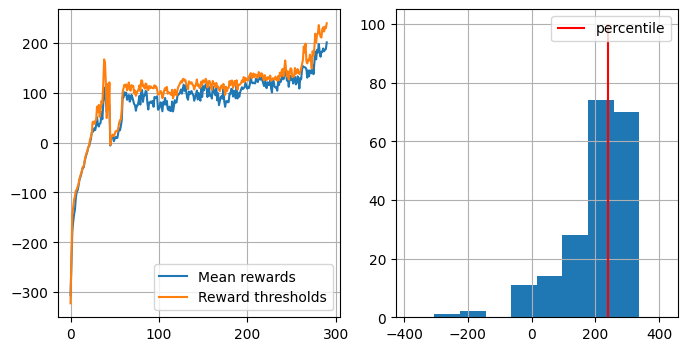

It works well enough


In [ ]:
# петля обчуения для непрерывного случая

from sklearn.neural_network import MLPRegressor
from joblib import Parallel, delayed
from collections import deque

agent = MLPRegressor(
    hidden_layer_sizes=(64, 64, 64, 64),
    activation="relu",
    learning_rate_init= 0.001
)

n_workers = 12
n_sessions = 200
percentile =50
n_epochs = 500
t_max = 1000
deque_len = 4 
std = 1
std_min = 0.1
std_base = std

envs = ParralellEnvs("LunarLander-v3",n_workers=n_workers, continuous=True)
n_actions = envs.envs[0].action_space.low.shape[0]

# # initialize agent to the dimension of state space and number of actions
agent.partial_fit([envs.envs[0].reset()[0]] * n_actions, np.zeros(shape=(n_actions,n_actions)))

parallel = Parallel(n_jobs=n_workers, return_as="list")
log = []

# Добавил очередь для элит с прошлых эпох
states_deque = deque()
actions_deque = deque()
for i in range(n_epochs):
    print(f"iter num = {i}")
    # генерируем сесси в параллель
    sessions = parallel(delayed(envs.generate_session)(i, agent, t_max=t_max , std = std) for i in range(n_sessions))

    states_batch = [session[0] for session in sessions]
    actions_batch = [session[1] for session in sessions]
    rewards_batch = [session[2] for session in sessions]
    
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    states_deque.append(np.array(elite_states))
    actions_deque.append(np.array(elite_actions))

    for elite_states,elite_actions in zip(states_deque,actions_deque):
        if len(elite_states) > 0:
            agent.partial_fit(elite_states,elite_actions)

    if len(states_deque) >= deque_len:
        states_deque.popleft()
        actions_deque.popleft()


    show_progress(
        rewards_batch, log, percentile, reward_range=[np.min(rewards_batch)-100, np.max(rewards_batch)+100]
    )

    if np.mean(rewards_batch) > 200:
        print("It works well enough")
        break

    if np.mean(rewards_batch) > -50 and np.mean(rewards_batch) < 50:
        std = std_min * (np.mean(rewards_batch)+50)/100 + std_base*(1 - (np.mean(rewards_batch)+50)/100)

In [99]:
import pickle

# Define the filename
filename = 'lunar_lander_continuous_agent.pkl'

# Open the file in write binary mode and dump the model
with open(filename, 'wb') as file:
    pickle.dump(agent, file)